# **1. Perkenalan Dataset**


**Deskripsi proyek**  
Notebook ini menggunakan Template Eksperimen MSML sebagai dasar eksperimen dataset pelatihan. Dataset yang digunakan adalah Breast Cancer Wisconsin dari `sklearn.datasets`. Tujuan eksperimen ini adalah memuat data, melakukan EDA, melakukan preprocessing, dan menyimpan dataset hasil preprocessing yang siap digunakan untuk pelatihan model machine learning.

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 20)
print('Library berhasil diimpor.')

Library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Dataset yang digunakan: Breast Cancer Wisconsin dari scikit-learn.
# Dataset ini berisi fitur numerik hasil pengukuran karakteristik sel dan target klasifikasi biner.

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['diagnosis_label'] = df['target'].map({0: 'malignant', 1: 'benign'})

raw_output_path = Path('..') / 'breast_cancer_raw.csv'
df.to_csv(raw_output_path, index=False)

print('Dataset berhasil dimuat.')
print('Sumber dataset: sklearn.datasets.load_breast_cancer')
print('Jumlah baris dan kolom:', df.shape)
print('File raw disimpan ke:', raw_output_path)
display(df.head())

Dataset berhasil dimuat.
Sumber dataset: sklearn.datasets.load_breast_cancer
Jumlah baris dan kolom: (569, 32)
File raw disimpan ke: ../breast_cancer_raw.csv


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothn

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis_label
missing_values,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Jumlah data duplikat: 0

Distribusi target:


,count
diagnosis_label,
benign,357
malignant,212



Statistik deskriptif fitur numerik:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


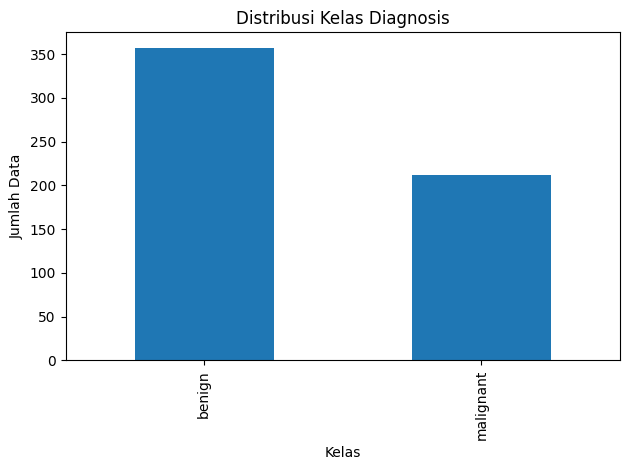

In [3]:
print('Informasi dataset:')
print(df.info())

print('\nJumlah nilai kosong per kolom:')
display(df.isna().sum().to_frame('missing_values').T)

print('\nJumlah data duplikat:', df.duplicated().sum())

print('\nDistribusi target:')
display(df['diagnosis_label'].value_counts().to_frame('count'))

print('\nStatistik deskriptif fitur numerik:')
display(df.drop(columns=['diagnosis_label']).describe().T.head(10))

# Visualisasi distribusi kelas
ax = df['diagnosis_label'].value_counts().plot(kind='bar', title='Distribusi Kelas Diagnosis')
ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah Data')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Preprocessing dilakukan dengan tahapan berikut:
# 1. Menghapus kolom diagnosis_label karena hanya dipakai untuk EDA.
# 2. Memisahkan fitur dan target.
# 3. Melakukan standardisasi fitur numerik dengan StandardScaler.
# 4. Menyimpan dataset preprocessing yang siap dilatih.

feature_columns = [col for col in df.columns if col not in ['target', 'diagnosis_label']]
X = df[feature_columns]
y = df['target'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

processed_df = pd.DataFrame(X_scaled, columns=feature_columns)
processed_df['target'] = y.values

processed_output_path = Path('breast_cancer_preprocessing.csv')
processed_df.to_csv(processed_output_path, index=False)

X_train, X_test, y_train, y_test = train_test_split(
    processed_df.drop(columns=['target']),
    processed_df['target'],
    test_size=0.2,
    random_state=42,
    stratify=processed_df['target']
)

print('Preprocessing selesai.')
print('Jumlah data hasil preprocessing:', processed_df.shape)
print('Jumlah data training:', X_train.shape)
print('Jumlah data testing:', X_test.shape)
print('File preprocessing disimpan ke:', processed_output_path)
display(processed_df.head())

Preprocessing selesai.
Jumlah data hasil preprocessing: (569, 31)
Jumlah data training: (455, 30)
Jumlah data testing: (114, 30)
File preprocessing disimpan ke: breast_cancer_preprocessing.csv


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0


**Ringkasan**  
Dataset berhasil dimuat dan dieksplorasi melalui pemeriksaan struktur data, nilai kosong, duplikasi, distribusi target, dan statistik deskriptif. Proses preprocessing menghasilkan data numerik yang telah distandardisasi menggunakan `StandardScaler`. Hasil preprocessing disimpan sebagai `breast_cancer_preprocessing.csv` sehingga dapat digunakan kembali pada tahap modelling dan workflow CI.